# Intervalos de confianza

Este notebook calcula intervalos de confianza para la **media**, la **varianza** y la **desviacion estandar**. Puedes usar datos resumidos o introducir los datos individuales.

- Para la media se usa `z` cuando se conoce la desviacion poblacional y `t` cuando se estima con la desviacion muestral.
- El intervalo de la varianza requiere asumir que la poblacion sigue una distribucion normal.
- Cambia los valores de la siguiente celda y ejecuta las celdas en orden.

In [2]:
# ===================== DATOS EDITABLES =====================
# Puedes dejar datos_individuales como None y usar los resumenes.
datos_individuales = None
# Ejemplo: datos_individuales = [98, 103, 101, 95, 104, 99]

n = 30                         # numero de observaciones
media_muestral = 100          # media de la muestra
nivel_confianza = 95          # porcentaje: 90, 95, 99, etc.
sigma_poblacional = 12         # desviacion poblacional conocida; usa None si no la conoces
desviacion_muestral = 12       # s de la muestra; necesaria si sigma_poblacional es None
poblacion_normal = True        # necesario para el intervalo de varianza

calcular_varianza = True       # cambia a False si no deseas calcularla


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Si se introducen datos individuales, estos tienen prioridad sobre los resumenes.
if datos_individuales is not None:
    datos = np.asarray(datos_individuales, dtype=float)
    if datos.ndim != 1 or len(datos) < 2:
        raise ValueError('datos_individuales debe tener al menos dos valores.')
    n = len(datos)
    media_muestral = float(np.mean(datos))
    desviacion_muestral = float(np.std(datos, ddof=1))

if not isinstance(n, (int, np.integer)) or n < 2:
    raise ValueError('n debe ser un entero mayor o igual que 2.')
if not np.isfinite(media_muestral):
    raise ValueError('media_muestral debe ser un numero finito.')
if not 0 < nivel_confianza < 100:
    raise ValueError('nivel_confianza debe estar entre 0 y 100.')
if sigma_poblacional is not None and (not np.isfinite(sigma_poblacional) or sigma_poblacional <= 0):
    raise ValueError('sigma_poblacional debe ser None o un numero positivo.')
if desviacion_muestral is not None and (not np.isfinite(desviacion_muestral) or desviacion_muestral <= 0):
    raise ValueError('desviacion_muestral debe ser None o un numero positivo.')
if sigma_poblacional is None and desviacion_muestral is None:
    raise ValueError('Indica sigma_poblacional o desviacion_muestral.')

alpha = 1 - nivel_confianza / 100
gl = n - 1
desviacion_para_varianza = sigma_poblacional if sigma_poblacional is not None else desviacion_muestral

if sigma_poblacional is not None:
    distribucion_media = 'Normal (z)'
    valor_critico = stats.norm.ppf(1 - alpha / 2)
    error_maximo = valor_critico * sigma_poblacional / np.sqrt(n)
else:
    distribucion_media = 't de Student'
    valor_critico = stats.t.ppf(1 - alpha / 2, gl)
    error_maximo = valor_critico * desviacion_muestral / np.sqrt(n)

media_inferior = media_muestral - error_maximo
media_superior = media_muestral + error_maximo

if calcular_varianza and poblacion_normal:
    chi2_inferior = stats.chi2.ppf(alpha / 2, gl)
    chi2_superior = stats.chi2.ppf(1 - alpha / 2, gl)
    varianza_muestral = desviacion_muestral ** 2
    varianza_inferior = gl * varianza_muestral / chi2_superior
    varianza_superior = gl * varianza_muestral / chi2_inferior
    desviacion_inferior = np.sqrt(varianza_inferior)
    desviacion_superior = np.sqrt(varianza_superior)
else:
    varianza_inferior = varianza_superior = desviacion_inferior = desviacion_superior = np.nan

resumen = pd.DataFrame({
    'Intervalo': ['Media', 'Varianza', 'Desviacion estandar'],
    'Estimacion': [media_muestral, desviacion_para_varianza ** 2, desviacion_para_varianza],
    'Metodo': [distribucion_media, 'Chi-cuadrado' if poblacion_normal and calcular_varianza else 'No calculado', 'Chi-cuadrado' if poblacion_normal and calcular_varianza else 'No calculado'],
    'Valor critico': [valor_critico, np.nan, np.nan],
    'Error maximo': [error_maximo, np.nan, np.nan],
    'Limite inferior': [media_inferior, varianza_inferior, desviacion_inferior],
    'Limite superior': [media_superior, varianza_superior, desviacion_superior]
})

print(f'Nivel de confianza: {nivel_confianza}% | alfa: {alpha:.4f} | n: {n} | grados de libertad: {gl}')
display(resumen.round(4))

Nivel de confianza: 95% | alfa: 0.0500 | n: 30 | grados de libertad: 29


,Intervalo,Estimacion,Metodo,Valor critico,Error maximo,Limite inferior,Limite superior
0,Media,100,Normal (z),1.96,4.2941,95.7059,104.2941
1,Varianza,144,Chi-cuadrado,NaN,NaN,91.3340,260.2344
2,Desviacion estandar,12,Chi-cuadrado,NaN,NaN,9.5569,16.1318


## Graficos

El primer grafico muestra la distribucion utilizada para la media y el area central del intervalo. El segundo muestra los intervalos calculados para la varianza y la desviacion estandar.

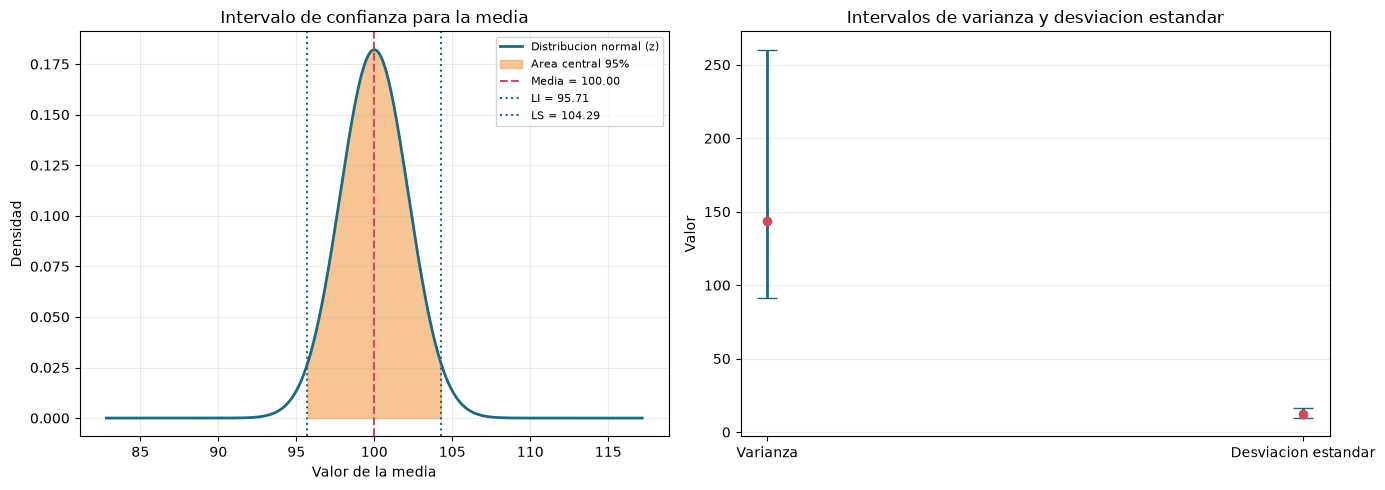

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribucion de la media y region de confianza
x = np.linspace(media_muestral - 4 * error_maximo, media_muestral + 4 * error_maximo, 600)
if sigma_poblacional is not None:
    escala = sigma_poblacional / np.sqrt(n)
    y = stats.norm.pdf(x, media_muestral, escala)
    etiqueta = 'Distribucion normal (z)'
else:
    escala = desviacion_muestral / np.sqrt(n)
    y = stats.t.pdf((x - media_muestral) / escala, gl) / escala
    etiqueta = 'Distribucion t de Student'

axes[0].plot(x, y, color='#176b87', linewidth=2, label=etiqueta)
region = (x >= media_inferior) & (x <= media_superior)
axes[0].fill_between(x, y, where=region, color='#f2a65a', alpha=0.65, label=f'Area central {nivel_confianza}%')
axes[0].axvline(media_muestral, color='#d1495b', linestyle='--', label=f'Media = {media_muestral:.2f}')
axes[0].axvline(media_inferior, color='#176b87', linestyle=':', label=f'LI = {media_inferior:.2f}')
axes[0].axvline(media_superior, color='#176b87', linestyle=':', label=f'LS = {media_superior:.2f}')
axes[0].set_title('Intervalo de confianza para la media')
axes[0].set_xlabel('Valor de la media')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

# Intervalos de varianza y desviacion estandar
if np.isfinite(varianza_inferior):
    etiquetas = ['Varianza', 'Desviacion estandar']
    estimaciones = [desviacion_para_varianza ** 2, desviacion_para_varianza]
    inferiores = [varianza_inferior, desviacion_inferior]
    superiores = [varianza_superior, desviacion_superior]
    errores = np.array([np.array(estimaciones) - np.array(inferiores), np.array(superiores) - np.array(estimaciones)])
    axes[1].errorbar(etiquetas, estimaciones, yerr=errores, fmt='o', color='#d1495b', ecolor='#176b87', capsize=7, linewidth=2)
    axes[1].set_title('Intervalos de varianza y desviacion estandar')
    axes[1].set_ylabel('Valor')
    axes[1].grid(axis='y', alpha=0.25)
else:
    axes[1].text(0.5, 0.5, 'Activa poblacion_normal y proporciona s\npara calcular este intervalo', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

### Interpretacion rapida

El intervalo indica un rango de valores plausibles para el parametro poblacional al nivel de confianza elegido. No significa que exista una probabilidad de que el parametro fijo este dentro de este intervalo concreto; significa que el procedimiento utilizado captura el parametro en aproximadamente ese porcentaje de muestras repetidas.